In [1]:
%load_ext autoreload
%autoreload 2

### Infer Held Out Transition Likelihoods using Original versus Finetuned Checkpoints

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.peint import EncodedPEINTDataset
from peint.models.modules.peint_module import PEINTModule, load_from_og_peint_checkpoint
from peint.models.nets.peint import PEINT

from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint-workspace/main/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
# load the old checkpoint from Antoine
# og_ckpt_path = "/scratch/users/stephen.lu/projects/protevo/checkpoints/antoine/epoch=2-step=40000.ckpt"
# module = load_from_og_peint_checkpoint(og_ckpt_path)

# load the new checkpoint from finetuning
new_ckpt_path = "/scratch/users/stephen.lu/projects/protevo/logs/train/runs/2026-04-11_13-16-04/checkpoints/epoch_068.ckpt"
module = PEINTModule.load_from_checkpoint(new_ckpt_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

net: PEINT = module.net.to(device)
vocab: Vocab = net.vocab
print(vocab)

Using device: cuda
Vocab({'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4, 'A': 5, 'G': 6, 'V': 7, 'S': 8, 'E': 9, 'R': 10, 'T': 11, 'I': 12, 'D': 13, 'P': 14, 'K': 15, 'Q': 16, 'N': 17, 'F': 18, 'Y': 19, 'M': 20, 'H': 21, 'W': 22, 'C': 23, 'X': 24, 'B': 25, 'U': 26, 'Z': 27, 'O': 28, '.': 29, '-': 30, '<null_1>': 31, '<mask>': 32})


/accounts/projects/yss/stephen.lu/peint-workspace/main/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [11]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = EncodedPEINTDataset(
        dataset=ComplexCherriesDataset(sep_token=".", data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        sep_token=".",
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        permute_chain_order=False,
        embed_x_per_chain=True,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def decode_sequence_from_toks(toks):
    tokens = []
    toks_to_skip = [
        vocab.bos_idx,
        vocab.unk_idx,
        vocab.tokens_to_idx["<mask>"],
        vocab.tokens_to_idx["<null_1>"],
        vocab.tokens_to_idx["-"],
    ]
    for tok in toks:
        if tok in toks_to_skip:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(ts.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [12]:
# load the test dataset
datapath = Path("/scratch/users/stephen.lu/projects/post-train/rubisco/library/cherries_test.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

Inference: 100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:01<00:00,  6.06it/s]


In [13]:
# save the results to a dataframe and to disk
print('test perplexity: ', np.mean(ppl))

df = pd.DataFrame({
    "t": bls[:,0],
    "ll": lls,
    "ppl": ppl,
})

df.to_csv("ft_ckpt_test_results.csv", index=False)

test perplexity:  2.0524209


### Plot the results

In [18]:
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

In [20]:
# load the two dataframes and merge them on the "t" column and add a column for the method (original vs finetuned)
df_ft = pd.read_csv("ft_ckpt_test_results.csv")
df_og = pd.read_csv("og_ckpt_test_results.csv")
df = pd.merge(df_ft, df_og, on="t", suffixes=("_ft", "_og"))
print(df.shape)
print(df.head())

(252, 5)
          t      ll_ft    ppl_ft      ll_og    ppl_og
0  0.137626 -189.90549  1.481684 -211.89023  1.550684
1  0.073315 -178.10379  1.453781 -376.88574  2.207315
2  0.120328 -118.88020  1.294902 -182.93962  1.488390
3  0.288409 -291.63263  1.835961 -338.86523  2.025809
4  0.119418 -151.62195  1.377891 -191.21512  1.498194


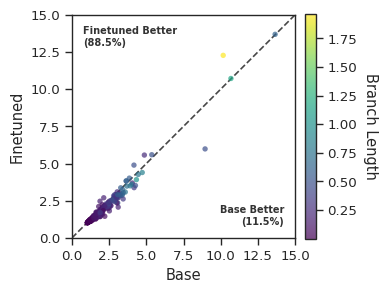

In [ ]:
# 1. Extract data directly from your existing dataframe 'df'
X = df['ppl_og']
Y = df['ppl_ft']
C = df['t']

# Lower is better for perplexity
pct_win_y = 100 * (Y < X).mean()
pct_win_x = 100 * (X < Y).mean()

# 2. Setup the scatter plot
plt.figure(figsize=(4, 4))
scatter = plt.scatter(X, Y, c=C, cmap='viridis', alpha=0.7, edgecolors='none', s=15)

# 3. Calculate absolute min and max for identical axes
# lim_min = min(X.min(), Y.min())
# lim_max = max(X.max(), Y.max())
lim_min, lim_max = 0, 15

# Add a small 5% padding so points don't hug the exact edge of the plot
padding = (lim_max - lim_min) * 0.05
# lim_min -= padding
# lim_max += padding

# Add the diagonal parity line
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.8, zorder=0)

# 4. Enforce square plot and identical axes
ax = plt.gca()
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

# adjustable='box' forces the physical plot area to remain a perfect square
ax.set_aspect('equal', adjustable='box') 

# Extract the auto-generated X ticks and force the Y axis to use the exact same ones
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_yticks(ticks)

plt.xlabel('Base')
plt.ylabel('Finetuned')

# Annotations
ax.text(lim_min + padding, lim_max - padding, f'Finetuned Better\n({pct_win_y:.1f}%)', 
        ha='left', va='top', fontweight='bold', fontsize=7, color='#333', zorder=5)
ax.text(lim_max - padding, lim_min + padding, f'Base Better\n({pct_win_x:.1f}%)', 
        ha='right', va='bottom', fontweight='bold', fontsize=7, color='#333', zorder=5)

# 5. Add colorbar
cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
cbar.set_label('Branch Length', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig("parity_ppl_ft_vs_og.pdf", bbox_inches='tight')
plt.show()

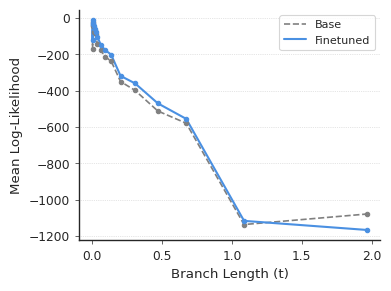

In [51]:
# Create a geometric grid of bins for branch length 't' (avoiding 0 for log scale)
t_min = max(df['t'].min(), 1e-4) 
t_max = df['t'].max()
# num=25 acts as the equivalent to your QUANTIZATION_POINTS
bins = np.geomspace(t_min, t_max, num=25) 

# Assign each row to a bin
df['t_bin'] = pd.cut(df['t'], bins=bins)

# Calculate the mean of 't', 'll_og', and 'll_ft' for each bin
# dropna() removes any bins that ended up empty
grouped = df.groupby('t_bin', observed=True)[['t', 'll_og', 'll_ft']].mean().dropna()

# Extract the x-axis values (the actual average 't' within that bin)
x_vals = grouped['t']

# Exponentiate the mean log-likelihoods (just like the reference script)
# y_base = np.exp(grouped['ll_og'])
# y_ft = np.exp(grouped['ll_ft'])
y_base = grouped['ll_og']
y_ft = grouped['ll_ft']

# Setup professional ICML-style theme
sns.set_theme(style="ticks", context="paper", font_scale=1.0)
fig, ax = plt.subplots(figsize=(4.0, 3.0))

# Plot Base (Using gray dashed line, similar to the "Random guess" baseline in reference)
ax.plot(x_vals, y_base, label='Base', color='gray', linestyle='--', linewidth=1.2, zorder=2)

# Plot Finetuned (Using a strong professional blue)
ax.plot(x_vals, y_ft, label='Finetuned', color='#4A90E2', linewidth=1.5, zorder=3)

# Add markers to the points so the quantization grid is visible (optional but recommended)
ax.scatter(x_vals, y_base, color='gray', s=10, zorder=4)
ax.scatter(x_vals, y_ft, color='#4A90E2', s=10, zorder=4)

# Formatting
# ax.set_xscale('log')
ax.set_xlabel('Branch Length (t)', fontweight='medium')
ax.set_ylabel('Mean Log-Likelihood', fontweight='medium')

# Grid and Legend (matching the reference script's subtle y-grid)
ax.grid(which='major', axis='y', linestyle=':', linewidth=0.5)
ax.legend(loc='upper right', frameon=True, fontsize=8)

# Clean up axes
sns.despine(ax=ax, top=True, right=True)
ax.tick_params(axis='both', which='major', length=3, width=0.5)

plt.tight_layout()
# plt.savefig('figure_likelihood_vs_branch_length.pdf', bbox_inches='tight')
plt.show()